In [ ]:
import pandas as pd
import scanpy as sc
import os
import squidpy as sq
import re
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
from scipy.stats import entropy


mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Not gzip-compatible; example in jupyterlab script
def load_vcf(file):
    if os.path.exists(file):
        
        # Load VCF results
        exclude = [i for i, line in enumerate(open(file)) if line.startswith('##')]
        if len(exclude)>0:
            skip_rows = max(exclude)+1
        else:
            skip_rows = None

        vcf = pd.read_csv(
            file,
            skiprows = skip_rows,
            sep = '\t')

        return vcf

def extract_feature(adata, feature):

    ad_subset = adata[:, adata.var['feature_types']==feature]

    obs_names = adata.obs.index.tolist()
    var_names = ad_subset.var_names
    array = ad_subset.X.toarray()

    df = pd.DataFrame(
        array,
        index=obs_names,
        columns=var_names
    )

    return df

def merge_granular_states(df, level_state, index_list=None):
    new_state_df = []
    for state in set(annotation_hierarchy[level_state]):
            cts_to_merge = annotation_hierarchy[annotation_hierarchy[level_state]==state]['annotation_granular'].tolist()
            cts_to_merge = [i for i in cts_to_merge if i in df.columns]
            if len(cts_to_merge)>0:
                if index_list is not None:
                    indices = [i for i in index_list if i in df.columns]
                    df = df.set_index(indices)
                col = df[cts_to_merge].sum(axis=1)
                col.name = state
                new_state_df.append(col)
    new_state_df = pd.concat(new_state_df, axis=1, ignore_index=False)
    return new_state_df

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, Future

In [ ]:
visium_dir = '/nfs/team283/GBM_LEAP/GBM_LEAP_annotations/web_atlas/anndata/'
visium_files = os.listdir(visium_dir)
visium_files = [i for i in visium_files if 'h5ad' in i]

registration=False

## This code is horrifyingly bad; rewrite if given the opportunity 
slides = {}
for visium_file in visium_files:
    
    # load cell2loc adata and merge ROI metadata
    adata = sc.read_h5ad(visium_dir+visium_file)
    adata.obs['barcode'] = [re.sub('_.*$', '', i) for i in adata.obs.index.tolist()]
    slides[visium_file] = adata

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/annd

In [ ]:
spacetree_dir = '/nfs/team283/GBM_LEAP/GBM_LEAP_annotations/spacetree_new/'
#spacetree_files = [spacetree_dir+i for i in os.listdir(spacetree_dir) if 'at3' in i]

spacetree_files = os.listdir(spacetree_dir)

spacetree_df = []
for file in spacetree_files:
    adata_obs = sc.read_h5ad(spacetree_dir+file).obs
    adata_obs['barcodes'] = [re.sub('^.*_', '', i) for i in adata_obs.index]
    adata_obs['spaceranger_id']  = [re.sub('A_.*$', 'A', i) for i in adata_obs.index]
    adata_obs.index = adata_obs['barcodes'].astype(str)+'_'+adata_obs['spaceranger_id'].astype(str)

    spacetree_df.append(adata_obs)
spacetree_df = pd.concat(spacetree_df)

all_clones = [str(i) for i in range(11) if str(i) in spacetree_df.columns]+['diploid']
spacetree_df = spacetree_df[all_clones]

# merge with main analysis df for PDID compat.
for file in visium_files:    
    if spacetree_df.columns[0] not in slides[file].obs.columns:
        slides[file].obs = slides[file].obs.reset_index().merge(
                spacetree_df.reset_index(), on = 'index', how = 'left').set_index('index')

# Entropy per purity bin

In [ ]:
global_summary = []
for file in slides:
    
    # get clone info
    st_df = slides[file].obs
    st_df = st_df[all_clones].dropna(axis=0, how = 'all').dropna(axis=1, how = 'all')
    
    clone_entropy = st_df.apply(entropy, axis=1)
    clone_entropy_normalised = clone_entropy/np.log(len(st_df.columns))

    if 'diploid' in st_df.columns:
        maligant_prob = 1-st_df['diploid']
    else:
        maligant_prob = 1
    
    # get niche info
    sn_df = extract_feature(slides[file], 'Spatial niche abundances')
    
    st_df = st_df.reset_index().merge(sn_df.reset_index(), on = 'index', how = 'left').set_index('index')
    
    st_df['clone_entropy'] = clone_entropy
    st_df['clone_entropy_normalised'] = clone_entropy_normalised
    st_df['maligant_prob'] = maligant_prob

    st_df['sample'] = file
    
    global_summary.append(st_df)
global_summary = pd.concat(global_summary)

/tmp/ipykernel_957648/993789458.py:9: RuntimeWarning: divide by zero encountered in log
  clone_entropy_normalised = clone_entropy/np.log(len(st_df.columns))
/tmp/ipykernel_957648/993789458.py:9: RuntimeWarning: divide by zero encountered in log
  clone_entropy_normalised = clone_entropy/np.log(len(st_df.columns))
/tmp/ipykernel_957648/993789458.py:9: RuntimeWarning: divide by zero encountered in log
  clone_entropy_normalised = clone_entropy/np.log(len(st_df.columns))
/tmp/ipykernel_957648/993789458.py:9: RuntimeWarning: divide by zero encountered in log
  clone_entropy_normalised = clone_entropy/np.log(len(st_df.columns))
/tmp/ipykernel_957648/993789458.py:9: RuntimeWarning: divide by zero encountered in log
  clone_entropy_normalised = clone_entropy/np.log(len(st_df.columns))
/tmp/ipykernel_957648/993789458.py:9: RuntimeWarning: divide by zero encountered in log
  clone_entropy_normalised = clone_entropy/np.log(len(st_df.columns))
/tmp/ipykernel_957648/993789458.py:9: RuntimeWarning

In [ ]:
list(pd.cut(global_summary.maligant_prob, bins = 20).unique())
labels = ["0-0.5","0.5-0.1","0.1-0.15","0.15-0.2","0.2-0.25",
"0.25-0.3","0.3-0.35","0.35-0.4","0.4-0.45","0.45-0.5","0.5-0.55",
"0.55-0.6","0.6-0.65","0.65-0.7","0.7-0.75","0.75-0.8","0.8-0.85",
"0.85-0.9","0.9-0.95","0.95-1"]

In [ ]:
plt.figure(figsize = (5,3))
ax = sns.boxplot(x =pd.cut(global_summary.maligant_prob, 
                           bins = [0,0.02,0.04,0.06,0.08,0.1,0.15,0.2,0.4,0.6,0.8,1]),
                  y = global_summary.clone_entropy_normalised,
                 palette= "Purples_r", fliersize = 1)
ax.set_xlabel("Tumor purity")
ax.set_ylabel("Spot entropy (clone mapping)")
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.savefig('../data/spacetree_plots/purity_plot.pdf')
global_summary[['clone_entropy_normalised', 'maligant_prob']]\
    .to_csv('../../../data/Fig4/Fig4h_entopy_purity.csv')
#set x tick labels

/tmp/ipykernel_957648/3319928608.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x =pd.cut(global_summary.maligant_prob,


# Purity per niche

In [ ]:
# originally done by taking idxmax of niche id
niches = ['Pial layer', 'Immune (TAMs)',
       'Proliferative', 'Dev-like (AC)', 'Grey matter', 'Gliosis transition',
       'White matter', 'Hypoxic 1 (niche)', 'Gliosis', 'Vasculature',
       'Immune (resident)', 'Gliosis (diffuse)', 'Hypoxic 2 (niche)',
       'Dev-like (OPC)', 'Dev-like (Neuron)', 'Astrocyte rich']

# only use niches very representative of the biology (apply filter)
global_summary_niches = global_summary.copy()
global_summary_niches['top_niche'] = global_summary_niches[niches].idxmax(axis=1)
global_summary_niches['global_summary_frac_max'] = global_summary_niches[niches].divide(
    global_summary_niches[niches].sum(axis=1), axis=0).max(axis=1)
global_summary_niches['global_summary_max'] = global_summary_niches[niches].max(axis=1)

global_summary_niches = global_summary_niches[global_summary_niches['global_summary_frac_max']>0.5]
global_summary_niches = global_summary_niches[global_summary_niches['global_summary_max']>4]

In [ ]:
global_summary_niches[['sample', 'top_niche']].drop_duplicates()['top_niche'].value_counts()

top_niche
Vasculature           72
Dev-like (AC)         65
White matter          51
Hypoxic 1 (niche)     50
Dev-like (OPC)        41
Gliosis transition    40
Gliosis               33
Proliferative         26
Grey matter           25
Immune (resident)     20
Immune (TAMs)         19
Gliosis (diffuse)     18
Hypoxic 2 (niche)     14
Pial layer            13
Astrocyte rich        11
Dev-like (Neuron)     10
Name: count, dtype: int64

In [ ]:
plot_df = (global_summary_niches.groupby(['sample', 'top_niche'], as_index=False)
    ['maligant_prob'].median())

order = plot_df.groupby('top_niche')['maligant_prob'].median().sort_values().index.tolist()

/tmp/ipykernel_3316954/4250204472.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data = plot_df,


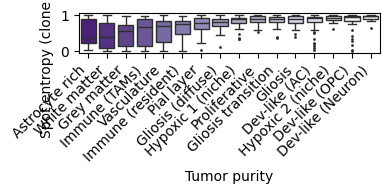

In [ ]:
plt.figure(figsize = (4,2))
ax = sns.boxplot(data = plot_df,
                  x = 'top_niche', 
                  y = 'maligant_prob', order = order,
                 palette= "Purples_r", fliersize = 1)
ax.set_xlabel("Tumor purity")
ax.set_ylabel("Spot entropy (clone mapping)")
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3316954/2221923288.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data = plot_df,
/tmp/ipykernel_3316954/2221923288.py:10: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


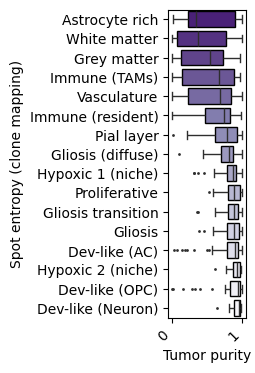

In [ ]:
plt.figure(figsize = (1,4))
ax = sns.boxplot(data = plot_df,
                  y = 'top_niche', 
                  x = 'maligant_prob', order = order,
                 palette= "Purples_r", fliersize = 1,
                 boxprops={"edgecolor": "black"})
ax.set_xlabel("Tumor purity")
ax.set_ylabel("Spot entropy (clone mapping)")
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.savefig('../data/spacetree_plots/niche_plot.pdf')
global_summary[['clone_entropy_normalised', 'maligant_prob']]\
    .to_csv('../../../data/EDFig5/EDFig5j_niche_purity.csv')